In [1]:
%matplotlib inline
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt
import numpy as np


Load the MNIST dataset

In [2]:
(train_data,train_target),(test_data,test_target) = mnist.load_data()

Visualize the dataset

Target labels:  [0 1 3 7 1 8 5 5 6 4]


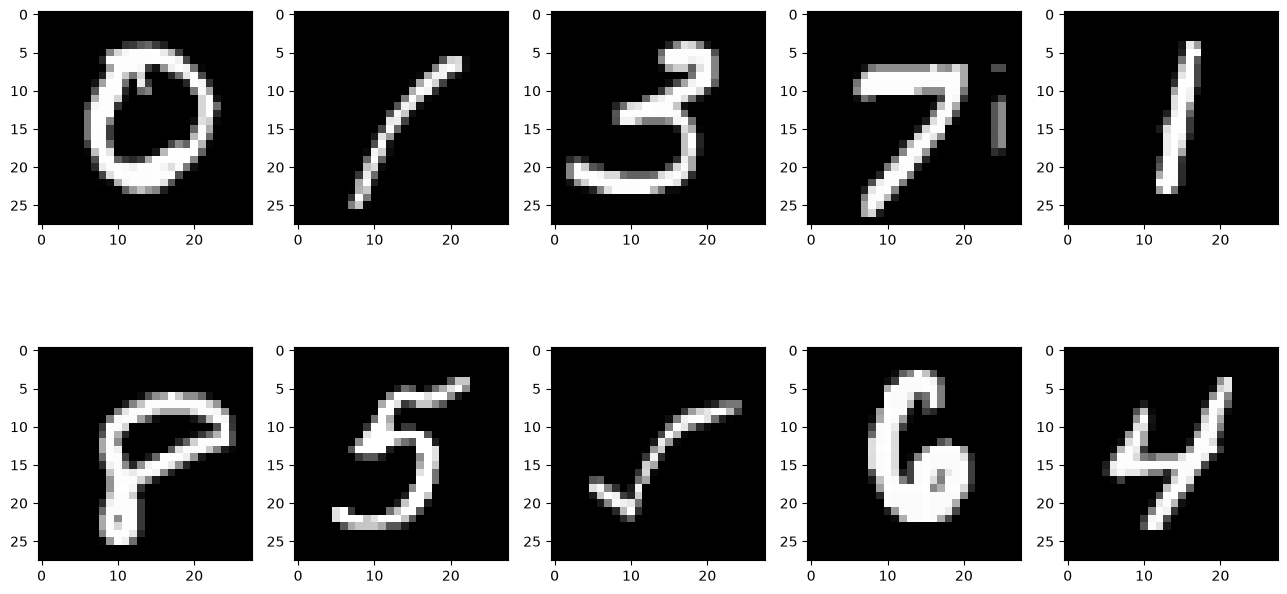

In [3]:
fig, axs = plt.subplots(2, 5, figsize=(16,8))
random_numbers = np.random.randint(0, 60000, 10)
print('Target labels: ',train_target[random_numbers])
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(train_data[random_numbers[idx]],cmap='gray')
plt.show()

Pre-processing stage

In [4]:
new_train_data = train_data/255.0
new_test_data=test_data/255.0

new_train_target = to_categorical(train_target)
new_test_target = to_categorical(test_target)

Create the Model architecture

In [5]:
model=Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(64,activation='relu'))
model.add(Dense(64,input_dim=64,activation='relu'))
model.add(Dense(32,input_dim=64,activation='relu'))
model.add(Dense(10,input_dim=32,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

C:\Users\LENOVO\Desktop\SE4050-Deep-Learning-Lab02\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\LENOVO\Desktop\SE4050-Deep-Learning-Lab02\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,810 (221.91 KB)

 Trainable params: 56,810 (221.91 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [7]:
train_info = model.fit(new_train_data , new_train_target , epochs = 10)

Epoch 1/10


   1/1875 ━━━━━━━━━━━━━━━━━━━━ 1:17:38 2s/step - accuracy: 0.1250 - loss: 2.2932

  15/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2812 - loss: 2.2012    

  28/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3973 - loss: 2.0239

  40/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4641 - loss: 1.8580

...

1822/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9895 - loss: 0.0305

1837/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9896 - loss: 0.0305

1852/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9896 - loss: 0.0304

1867/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9895 - loss: 0.0304

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9895 - loss: 0.0303


Plot the loss and accuracy graphs

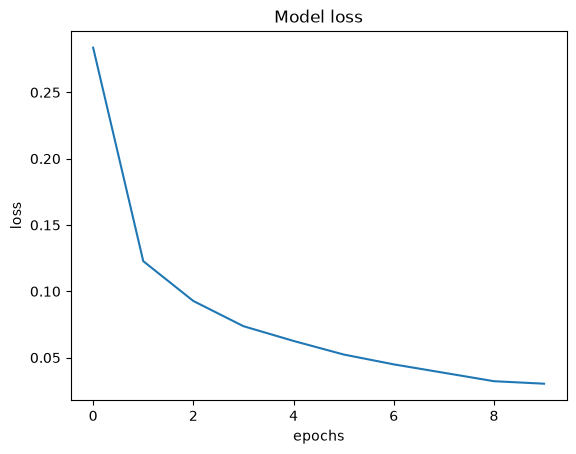

In [8]:
plt.plot(train_info.history['loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Model loss')
plt.show()

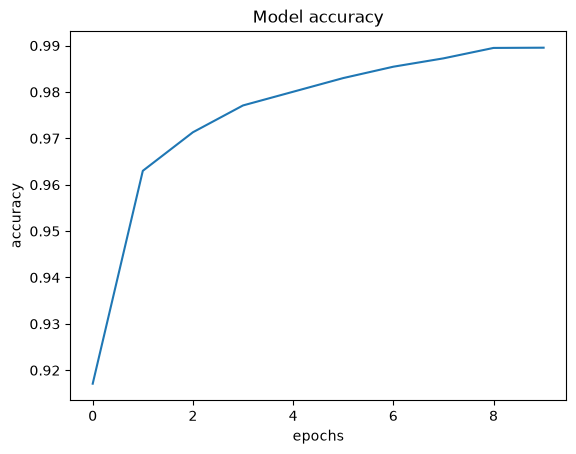

In [9]:
plt.plot(train_info.history['accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Model accuracy')
plt.show()

Test the performance of Model

In [10]:
loss, acc = model.evaluate(new_test_data , new_test_target)
print(f'Loss of the Test dataset is: {loss}\nAccuracy of the test dataset is: {acc}')

  1/313 ━━━━━━━━━━━━━━━━━━━━ 1:44 336ms/step - accuracy: 0.9688 - loss: 0.0470

 21/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9762 - loss: 0.0945    

 41/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9718 - loss: 0.1061

 60/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9703 - loss: 0.1158

 80/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9695 - loss: 0.1187

...

278/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9754 - loss: 0.0894

295/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9763 - loss: 0.0865

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9761 - loss: 0.0894

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9761 - loss: 0.0892


Loss of the Test dataset is: 0.08922456949949265
Accuracy of the test dataset is: 0.9761000275611877


Save the model weights

In [11]:
# Keras 3 requires the weights filename to end with .weights.h5
model.save_weights('MNIST_WEIGHTS_V1.weights.h5')

## Exercise 3 — Hyperparameter tuning, regularization, and confusion matrix

**Original (baseline) settings**
- Architecture: Flatten(28×28) → Dense(64, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(10, softmax)
- Optimizer: Adam (Keras default learning rate 0.001)
- Epochs: 10
- Batch size: default 32
- Saved baseline test accuracy: ~0.9697

**Tuned settings**
- Architecture: Flatten(28×28) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(10, softmax)
- Optimizer: Adam
- Epochs: 15
- Batch size: 64


In [12]:
from tensorflow.keras.regularizers import l1_l2

print('Original vs tuned hyperparameters')
print('Original: hidden units 64-64-32, epochs=10, batch_size=32 (default), Adam')
print('Tuned:    hidden units 128-64-32, epochs=15, batch_size=64, Adam')

tuned_model = Sequential()
tuned_model.add(Flatten(input_shape=(28, 28)))
tuned_model.add(Dense(128, activation='relu'))
tuned_model.add(Dense(64, activation='relu'))
tuned_model.add(Dense(32, activation='relu'))
tuned_model.add(Dense(10, activation='softmax'))
tuned_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
tuned_model.summary()

Original vs tuned hyperparameters
Original: hidden units 64-64-32, epochs=10, batch_size=32 (default), Adam
Tuned:    hidden units 128-64-32, epochs=15, batch_size=64, Adam


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
tuned_info = tuned_model.fit(new_train_data, new_train_target, epochs=15, batch_size=64)

Epoch 1/15


  1/938 ━━━━━━━━━━━━━━━━━━━━ 42:52 3s/step - accuracy: 0.1094 - loss: 2.2832

  9/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2691 - loss: 2.1487  

 17/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3897 - loss: 1.9517

 25/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4600 - loss: 1.7615

...

899/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9949 - loss: 0.0154

909/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9949 - loss: 0.0154

920/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9949 - loss: 0.0155

930/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9949 - loss: 0.0155

938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9949 - loss: 0.0155


In [14]:
tuned_loss, tuned_acc = tuned_model.evaluate(new_test_data, new_test_target)
print(f'Tuned test loss: {tuned_loss}')
print(f'Tuned test accuracy: {tuned_acc}')

  1/313 ━━━━━━━━━━━━━━━━━━━━ 1:43 331ms/step - accuracy: 0.9688 - loss: 0.1150

 18/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9774 - loss: 0.0838    

 36/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9740 - loss: 0.1369

 56/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9671 - loss: 0.1606

 74/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9649 - loss: 0.1614

...

276/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9749 - loss: 0.1098

295/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9760 - loss: 0.1059

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9754 - loss: 0.1093

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.1091


Tuned test loss: 0.109111487865448
Tuned test accuracy: 0.9753999710083008


**B. L1 + L2 regularization**

A regularized copy of the tuned MLP (128 → 64 → 32) with `l1=1e-5` and `l2=1e-4` on the hidden Dense layers.

In [15]:
L1 = 1e-5
L2 = 1e-4
print(f'L1 = {L1}, L2 = {L2}')

regularizer = l1_l2(l1=L1, l2=L2)

reg_model = Sequential()
reg_model.add(Flatten(input_shape=(28, 28)))
reg_model.add(Dense(128, activation='relu', kernel_regularizer=regularizer))
reg_model.add(Dense(64, activation='relu', kernel_regularizer=regularizer))
reg_model.add(Dense(32, activation='relu', kernel_regularizer=regularizer))
reg_model.add(Dense(10, activation='softmax'))
reg_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
reg_model.summary()

reg_info = reg_model.fit(new_train_data, new_train_target, epochs=15, batch_size=64)

L1 = 1e-05, L2 = 0.0001


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

...

913/938 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9908 - loss: 0.0902

921/938 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9907 - loss: 0.0905

929/938 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9906 - loss: 0.0906

938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9905 - loss: 0.0909

938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9905 - loss: 0.0909


In [16]:
reg_loss, reg_acc = reg_model.evaluate(new_test_data, new_test_target)
print(f'Regularized test loss: {reg_loss}')
print(f'Regularized test accuracy: {reg_acc}')
print(f'L1 = {L1}, L2 = {L2}')

  1/313 ━━━━━━━━━━━━━━━━━━━━ 2:12 424ms/step - accuracy: 0.9688 - loss: 0.0911

 15/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9833 - loss: 0.1105    

 34/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9816 - loss: 0.1311

 50/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9737 - loss: 0.1543

 66/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9721 - loss: 0.1590

...

263/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9765 - loss: 0.1406

282/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9774 - loss: 0.1372

301/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9783 - loss: 0.1343

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9772 - loss: 0.1372


Regularized test loss: 0.13724318146705627
Regularized test accuracy: 0.9771999716758728
L1 = 1e-05, L2 = 0.0001


**C. Confusion matrix**

Class-wise test performance of the final regularized MLP on digits 0–9.

  1/313 ━━━━━━━━━━━━━━━━━━━━ 33s 108ms/step

 22/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   

 50/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 73/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 99/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

...

242/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

264/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

292/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


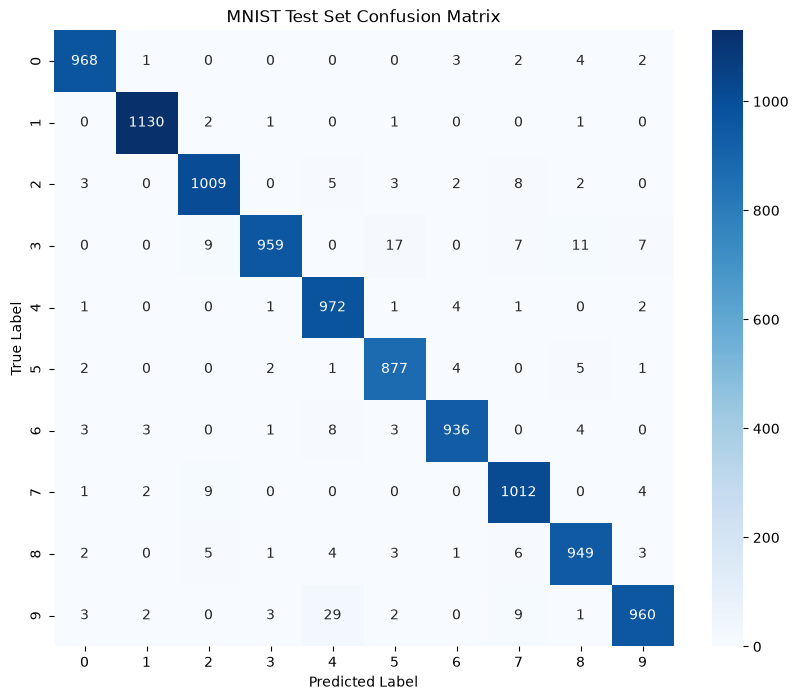

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_prob = reg_model.predict(new_test_data)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(new_test_target, axis=1)

cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('MNIST Test Set Confusion Matrix')
plt.show()